<a href="https://colab.research.google.com/github/Solu-victoria/SS-DLI-Research/blob/main/Experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
from google.colab import userdata
email = userdata.get('gb_email')
name = userdata.get('gb_name')
secret_key = userdata.get('gb_secret_key')

In [ ]:
!git clone https://{secret_key}@github.com/Solu-victoria/SS-DLI-Research.git

Cloning into 'SS-DLI-Research'...
remote: Enumerating objects: 117, done.
remote: Counting objects: 100% (117/117), done.
remote: Compressing objects: 100% (97/97), done.
remote: Total 117 (delta 35), reused 71 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (117/117), 1.09 MiB | 14.83 MiB/s, done.
Resolving deltas: 100% (35/35), done.


In [13]:
!git config --global user.email {email}
!git config --global user.name {name}

In [ ]:
%cd SS-DLI-Research/

/content/SS-DLI-Research


In [5]:
!git add .

In [6]:
!git commit -m 'recorded results for 100 steps per ep v2 about to do 300 steps'

[main 0c3cf3d] recorded results for 100 steps per ep v2 about to do 300 steps
 18 files changed, 8 insertions(+), 6 deletions(-)
 rename images/{ => v1}/experiment 1-v1.png (100%)
 rename images/{ => v1}/experiment 2-v1.png (100%)
 rename images/{ => v1}/experiment 3-v1.png (100%)
 create mode 100644 images/v2/100_steps_per_ep/experiment 1.1-v2-100stepsperep.png
 create mode 100644 images/v2/100_steps_per_ep/experiment 1.2-v2-100stepsperep.png
 create mode 100644 images/v2/100_steps_per_ep/experiment 2-v2-100stepsperep.png
 create mode 100644 images/v2/100_steps_per_ep/experiment 3-v2-100stepsperep.png
 rename models/v2/{ => 100_steps_per_ep}/baseline/run_1.pth (100%)
 rename models/v2/{ => 100_steps_per_ep}/baseline/run_2.pth (100%)
 rename models/v2/{ => 100_steps_per_ep}/baseline/run_3.pth (100%)
 rename models/v2/{ => 100_steps_per_ep}/baseline/run_4.pth (100%)
 rename models/v2/{ => 100_steps_per_ep}/baseline/run_5.pth (100%)
 rename models/v2/{ => 100_steps_per_ep}/multi/run_1.pt

In [14]:
!git push

Enumerating objects: 17, done.
Counting objects: 100% (17/17), done.
Delta compression using up to 2 threads
Compressing objects: 100% (10/10), done.
Writing objects: 100% (12/12), 289.25 KiB | 13.15 MiB/s, done.
Total 12 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/Solu-victoria/SS-DLI-Research.git
   644ff0b..0c3cf3d  main -> main


In [ ]:
!git pull

remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 3 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 290.16 KiB | 6.31 MiB/s, done.
From https://github.com/Solu-victoria/SS-DLI-Research
   d0adaae..644ff0b  main       -> origin/main
Updating d0adaae..644ff0b
Fast-forward
 Experiments.ipynb | 4162 +++++++++++++++++++++++++++--------------------------
 1 file changed, 2115 insertions(+), 2047 deletions(-)


## EXPERIMENT 1 — Learning Curve Comparison

In [ ]:
from train import run_train_experiment
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
baseline_runs, multi_runs = run_train_experiment(num_runs=5, episodes=200, num_steps_per_ep=300)


Run 1/5


/content/SS-DLI-Research/agent.py:51: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  states = torch.FloatTensor(states)


Baseline | Episode 0 | Reward: -2.74
Baseline | Episode 1 | Reward: 10.00
Baseline | Episode 2 | Reward: 5.14
Baseline | Episode 3 | Reward: -8.31
Baseline | Episode 4 | Reward: -3.50
Baseline | Episode 5 | Reward: -3.50
Baseline | Episode 6 | Reward: 14.55
Baseline | Episode 7 | Reward: 1.69
Baseline | Episode 8 | Reward: -1.94
Baseline | Episode 9 | Reward: -3.50
Baseline | Episode 10 | Reward: -5.12
Baseline | Episode 11 | Reward: 21.71
Baseline | Episode 12 | Reward: 19.56
Baseline | Episode 13 | Reward: -7.30
Baseline | Episode 14 | Reward: -1.57
Baseline | Episode 15 | Reward: 3.45
Baseline | Episode 16 | Reward: 7.22
Baseline | Episode 17 | Reward: 11.85
Baseline | Episode 18 | Reward: 6.62
Baseline | Episode 19 | Reward: -9.50
Baseline | Episode 20 | Reward: -9.49
Baseline | Episode 21 | Reward: 2.25
Baseline | Episode 22 | Reward: -14.00
Baseline | Episode 23 | Reward: -11.00
Baseline | Episode 24 | Reward: 2.68
Baseline | Episode 25 | Reward: -3.50
Baseline | Episode 26 | Rew

In [ ]:
baseline_mean = baseline_runs.mean(axis=0)
baseline_std = baseline_runs.std(axis=0)

multi_mean = multi_runs.mean(axis=0)
multi_std = multi_runs.std(axis=0)

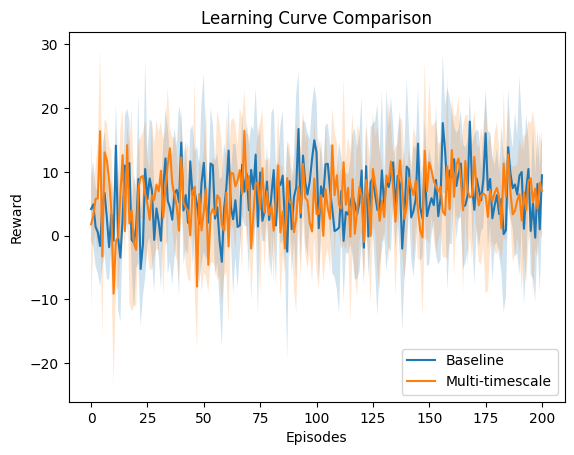

In [ ]:
plt.figure()

plt.plot(baseline_mean, label="Baseline")
plt.fill_between(
    range(len(baseline_mean)),
    baseline_mean - baseline_std,
    baseline_mean + baseline_std,
    alpha=0.2
)

plt.plot(multi_mean, label="Multi-timescale")
plt.fill_between(
    range(len(multi_mean)),
    multi_mean - multi_std,
    multi_mean + multi_std,
    alpha=0.2
)

plt.legend()
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.title("Learning Curve Comparison")

plt.show()

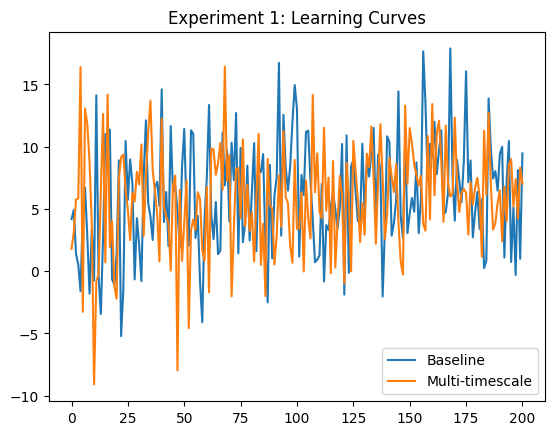

[ 4.1781531   4.91014632  1.36758864  0.53152283 -1.61651339  4.65800156
  6.69876127  2.80925033 -1.80371999  3.35765603 -0.75940035 14.12350779
 -0.36769032 -3.44603305  2.72310172 11.01218803 10.2098833  11.37889264
 -0.64958737 -1.09475613  1.34878909  8.89336291 -5.21941219 -1.39939152
 10.45783958  5.72790675  8.9697028   7.06305523 -0.66343909  4.25971621
  2.10314718 -0.8005679   7.60152959 12.11249043  5.49768391  4.40689474
  2.50327264  6.7140246   7.18202373  5.23295399 14.60352383  3.94136228
  6.35704345  2.01608098 11.65507054  6.32994226  6.85272711  4.8867072
  1.88089192  8.27660224 11.42359594  4.99414701  2.0472316  11.31351071
 11.04201721  2.67124875  4.4475137  -0.82587876 -4.10496914  4.23101533
  7.46548989 13.3473414   4.48049575  2.57567531  5.55846577  1.36503684
  1.6336127  11.11396976  6.88601796  9.70661458  4.00035017 10.32201598
  7.29500282 12.7034258   1.43427841  9.90388964  2.32886782  3.84279042
  8.4768755   2.46912888  6.41376932 10.28912351  1.

In [ ]:
# baseline_mean = baseline_runs.mean(axis=0)
# multi_mean = multi_runs.mean(axis=0)

plt.plot(baseline_mean, label="Baseline")
plt.plot(multi_mean, label="Multi-timescale")

plt.legend()
plt.title("Experiment 1: Learning Curves")
plt.show()
# print(baseline_mean)

## EXPERIMENT 2 — Learner Type Analysis

In [ ]:
from env import StudentEnv
from agent import Agent

def evaluate_student(agent, env, steps=100):
    state = env.reset()
    total_reward = 0

    for _ in range(steps):
        action = agent.select_action(state)
        state, reward, _, _ = env.step(action)
        total_reward += reward

    return total_reward

In [ ]:
baseline_agent = Agent(state_dim=2, action_dim=4)
multi_agent = Agent(state_dim=4, action_dim=4)

baseline_agent.load("models/v2/baseline/run_1.pth")
multi_agent.load("models/v2/multi/run_1.pth")

baseline_agent.epsilon = 0.0
multi_agent.epsilon = 0.0

In [ ]:
# Slow but strong learner
baseline_env = StudentEnv(multi_timescale=False)
baseline_env.true_ability = 0.8
baseline_env.true_speed = 0.3

baseline_score = evaluate_student(baseline_agent, baseline_env)

multitime_env = StudentEnv(multi_timescale=True)
multitime_env.true_ability = 0.8
multitime_env.true_speed = 0.3

multitime_score = evaluate_student(multi_agent, multitime_env)

print("Baseline:", baseline_score)
print("Multi:", multitime_score)

Baseline: 16.55627584830381
Multi: 19.036968191487166


## EXPERIMENT 3 — Stability / Variance

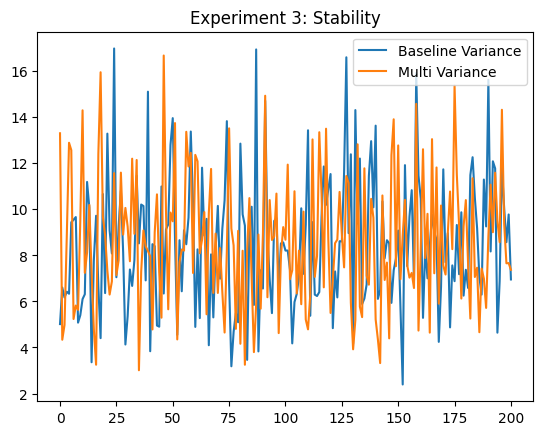

In [ ]:
baseline_std = baseline_runs.std(axis=0)
multi_std = multi_runs.std(axis=0)

plt.plot(baseline_std, label="Baseline Variance")
plt.plot(multi_std, label="Multi Variance")

plt.legend()
plt.title("Experiment 3: Stability")
plt.show()